In [1]:
import subprocess
import sys

packages = [
    "llmlingua",
    "pandas",
    "numpy",
    "matplotlib",
    "transformers",
    "torch",
    "sentencepiece",
    "accelerate",
]

for pkg in packages:
    print(f"Installing {pkg}...")
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", pkg, "--quiet"],
        capture_output=True,
        text=True
    )
    if result.returncode == 0:
        print(f"  {pkg} OK")
    else:
        print(f"  {pkg} ERROR : {result.stderr[:200]}")

print("\nAll packages installed")

Installing llmlingua...
  llmlingua OK
Installing pandas...
  pandas OK
Installing numpy...
  numpy OK
Installing matplotlib...
  matplotlib OK
Installing transformers...
  transformers OK
Installing torch...
  torch OK
Installing sentencepiece...
  sentencepiece OK
Installing accelerate...
  accelerate OK

All packages installed


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from llmlingua import PromptCompressor
import time
import textwrap
import warnings
warnings.filterwarnings("ignore")

# Load parquet file
df = pd.read_parquet("sm-calls_with_connectors.parquet")  

# Select 5 earning calls with different permno
sample = (
    df.dropna(subset=["text", "permno"])
    .drop_duplicates(subset="permno")
    .head(5)
    .reset_index(drop=True)
)

print(f"{len(sample)} calls selected")
print(sample[["permno", "companyname", "mostimportantdateutc", "word_count"]])

/home/bultez/miniconda3/envs/nanofm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


5 calls selected
    permno                     companyname mostimportantdateutc  word_count
0  80191.0           Albemarle Corporation           2008-01-29       10905
1  79323.0        The Allstate Corporation           2008-01-30       10167
2  84788.0                Amazon.com, Inc.           2006-02-02        7182
3  85271.0          American Capital, Ltd.           2009-03-02       15072
4  12591.0  Apollo Global Management, Inc.           2012-02-10        8222


In [3]:
compressor = PromptCompressor(
    model_name="microsoft/llmlingua-2-xlm-roberta-large-meetingbank",
    use_llmlingua2=True,
    device_map="cuda"
)
print("LLMLingua-2 loaded")

LLMLingua-2 loaded


In [4]:
RATES = [0.3, 0.15, 0.05]  # 30%, 15%, 5% of tokens kept
FORCE_TOKENS = [
    "$", "%", "EPS", "EBITDA", "revenue", "guidance",
    "margin", "volume", "growth", "inflation", "billion",
    "million", "quarter", "year", "outlook", "guidance"
]

results = []

for idx, row in sample.iterrows():
    print(f"\n{'='*60}")
    print(f"[{idx+1}/5] {row['companyname']} | permno={int(row['permno'])} | {row['mostimportantdateutc']}")
    print(f"  Original text: {row['word_count']:,} words | {len(row['text']):,} chars")

    row_results = {
        "permno": int(row["permno"]),
        "company": row["companyname"],
        "date": row["mostimportantdateutc"],
        "original_words": row["word_count"],
        "original_chars": len(row["text"]),
        "original_text": row["text"],
        "compressions": {}
    }

    for rate in RATES:
        try:
            t0 = time.time()
            out = compressor.compress_prompt(
                row["text"],
                rate=rate,
                force_tokens=FORCE_TOKENS
            )
            elapsed = time.time() - t0

            compressed_text = out["compressed_prompt"]
            compressed_words = len(compressed_text.split())
            actual_ratio = row["word_count"] / max(compressed_words, 1)

            row_results["compressions"][rate] = {
                "compressed_text": compressed_text,
                "compressed_words": compressed_words,
                "compressed_chars": len(compressed_text),
                "target_ratio": f"{1/rate:.1f}x",
                "actual_ratio": actual_ratio,
                "time_sec": round(elapsed, 2),
                "fits_pit": compressed_words <= 1500  # PIT-4B context window
            }

            fits = "OK" if compressed_words <= 1500 else "TOO LONG"
            print(f"  rate={rate} -> {compressed_words:,} words | ratio={actual_ratio:.1f}x | {elapsed:.1f}s | PIT-4B: {fits}")

        except Exception as e:
            print(f"  rate={rate} -> ERROR: {e}")
            row_results["compressions"][rate] = None

    results.append(row_results)

print("\nCompression completed for all samples")

Token indices sequence length is longer than the specified maximum sequence length for this model (14891 > 512). Running this sequence through the model will result in indexing errors



[1/5] Albemarle Corporation | permno=80191 | 2008-01-29 00:00:00
  Original text: 10,905 words | 63,457 chars
  rate=0.3 -> 2,923 words | ratio=3.7x | 4.3s | PIT-4B: TOO LONG
  rate=0.15 -> 1,351 words | ratio=8.1x | 1.1s | PIT-4B: OK
  rate=0.05 -> 451 words | ratio=24.2x | 1.1s | PIT-4B: OK

[2/5] The Allstate Corporation | permno=79323 | 2008-01-30 00:00:00
  Original text: 10,167 words | 59,035 chars
  rate=0.3 -> 2,795 words | ratio=3.6x | 1.0s | PIT-4B: TOO LONG
  rate=0.15 -> 1,297 words | ratio=7.8x | 1.0s | PIT-4B: OK
  rate=0.05 -> 383 words | ratio=26.5x | 1.0s | PIT-4B: OK

[3/5] Amazon.com, Inc. | permno=84788 | 2006-02-02 00:00:00
  Original text: 7,182 words | 41,909 chars
  rate=0.3 -> 1,942 words | ratio=3.7x | 0.7s | PIT-4B: TOO LONG
  rate=0.15 -> 903 words | ratio=8.0x | 0.7s | PIT-4B: OK
  rate=0.05 -> 298 words | ratio=24.1x | 0.7s | PIT-4B: OK

[4/5] American Capital, Ltd. | permno=85271 | 2009-03-02 00:00:00
  Original text: 15,072 words | 83,182 chars
  rate=0

Token indices sequence length is longer than the specified maximum sequence length for this model (14057 > 1024). Running this sequence through the model will result in indexing errors


Computing token counts...
  Albemarle | rate=0.3 -> 4034 tokens | TOO LONG
  Albemarle | rate=0.15 -> 2029 tokens | OK
  Albemarle | rate=0.05 -> 703 tokens | OK
  The | rate=0.3 -> 3501 tokens | TOO LONG
  The | rate=0.15 -> 1784 tokens | OK
  The | rate=0.05 -> 565 tokens | OK
  Amazon.com, | rate=0.3 -> 2488 tokens | TOO LONG
  Amazon.com, | rate=0.15 -> 1233 tokens | OK
  Amazon.com, | rate=0.05 -> 386 tokens | OK
  American | rate=0.3 -> 5145 tokens | TOO LONG
  American | rate=0.15 -> 2600 tokens | TOO LONG
  American | rate=0.05 -> 795 tokens | OK
  Apollo | rate=0.3 -> 2862 tokens | TOO LONG
  Apollo | rate=0.15 -> 1452 tokens | OK
  Apollo | rate=0.05 -> 429 tokens | OK

Token counts computed



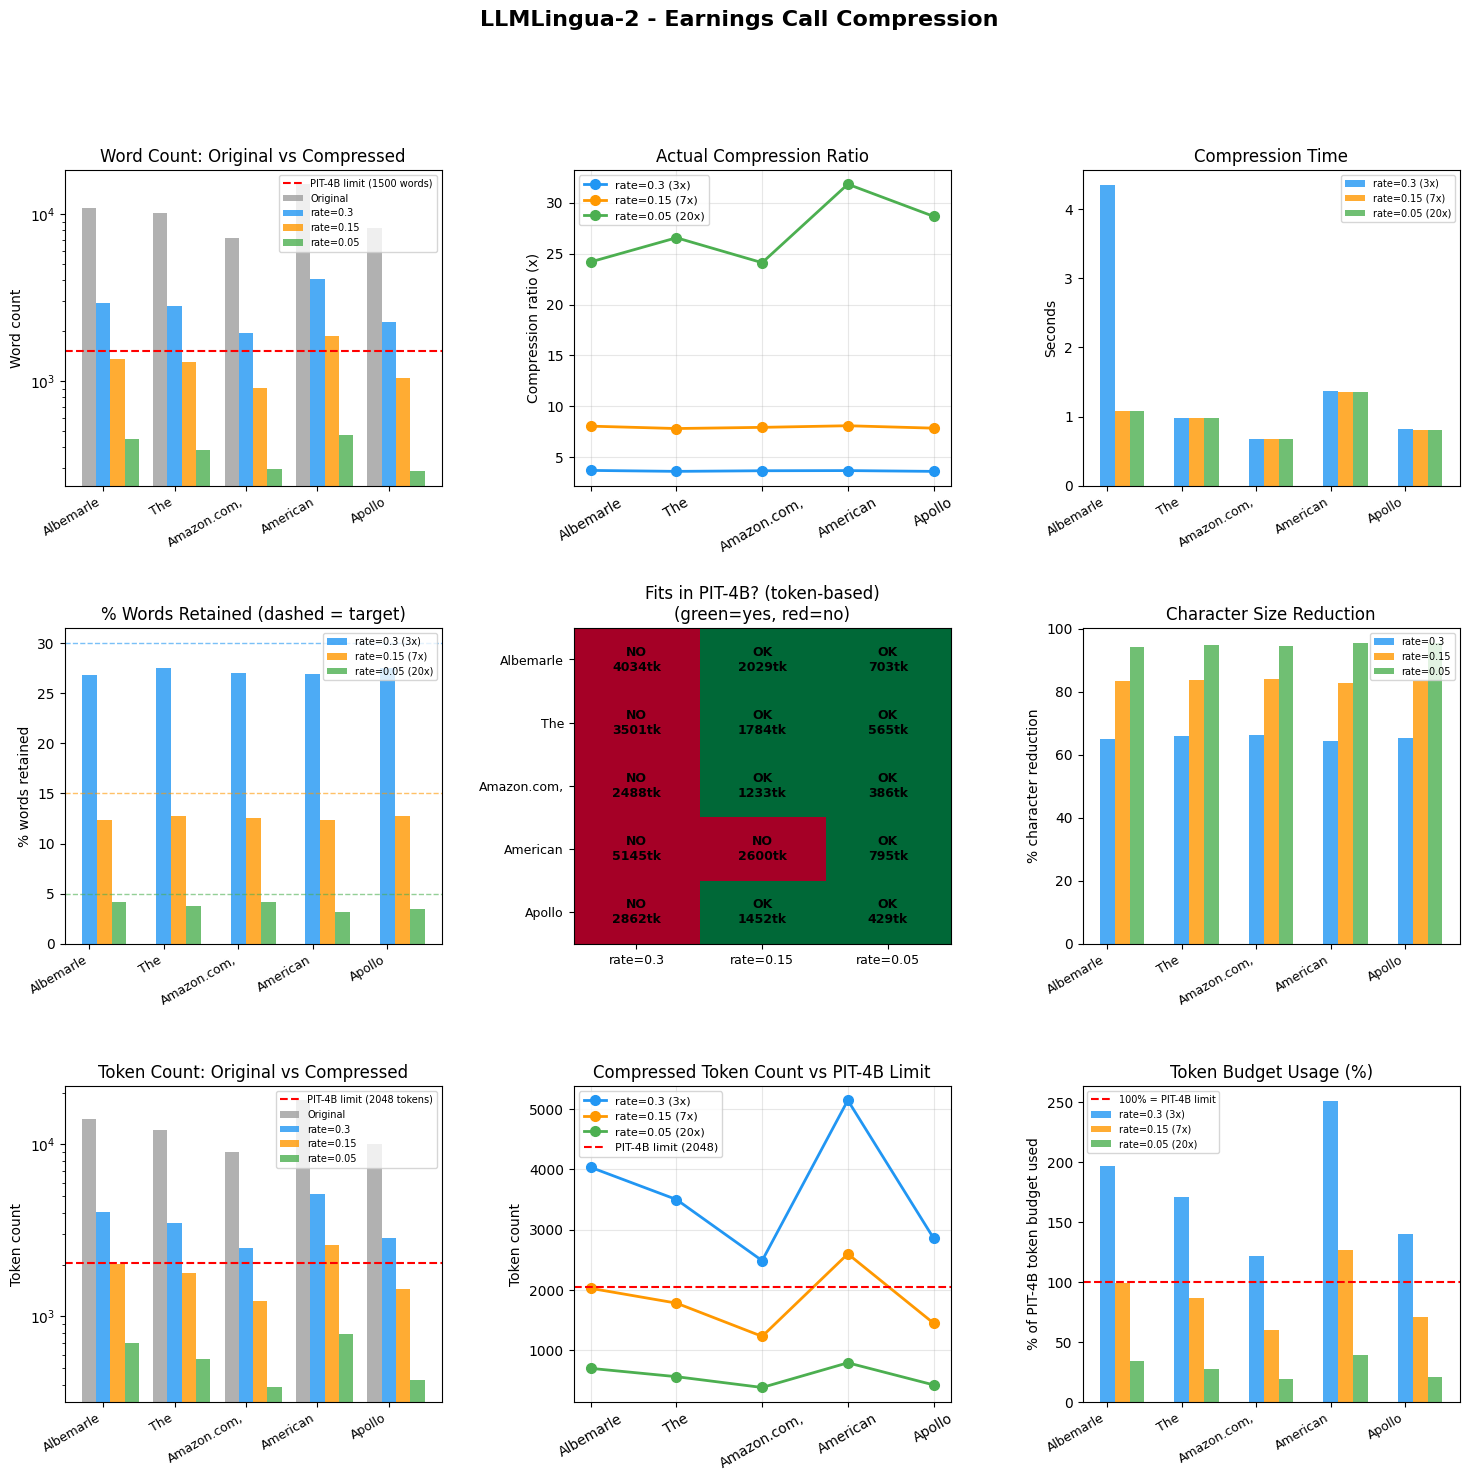

In [5]:
from transformers import AutoTokenizer

# Load tokenizer matching PIT-4B vocabulary (GPT2 tokenizer, vocab_size=50304)
tokenizer = AutoTokenizer.from_pretrained("gpt2")
PIT_MAX_TOKENS = 2048

# Compute token counts for original and compressed texts
print("Computing token counts...")
for r in results:
    r["original_tokens"] = len(tokenizer(r["original_text"])["input_ids"])
    for rate in RATES:
        comp = r["compressions"].get(rate)
        if comp:
            comp["compressed_tokens"] = len(tokenizer(comp["compressed_text"])["input_ids"])
            comp["fits_pit_tokens"]   = comp["compressed_tokens"] <= PIT_MAX_TOKENS
            fits = "OK" if comp["fits_pit_tokens"] else "TOO LONG"
            print(f"  {r['company'].split()[0]} | rate={rate} -> {comp['compressed_tokens']} tokens | {fits}")

print("\nToken counts computed\n")

# ============================================================
# Plots
# ============================================================
companies  = [r["company"].split()[0] for r in results]
orig_words = [r["original_words"] for r in results]
colors     = ["#2196F3", "#FF9800", "#4CAF50"]
rate_labels = [f"rate={r} ({1/r:.0f}x)" for r in RATES]

fig = plt.figure(figsize=(18, 16))
fig.suptitle("LLMLingua-2 - Earnings Call Compression", fontsize=16, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

x     = np.arange(len(companies))
width = 0.2

# --- Plot 1: Original vs Compressed Word Count ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(x - width, orig_words, width, label="Original", color="#9E9E9E", alpha=0.8)
for i, (rate, color) in enumerate(zip(RATES, colors)):
    comp_words = [
        r["compressions"][rate]["compressed_words"]
        if r["compressions"][rate] else 0
        for r in results
    ]
    ax1.bar(x + i * width, comp_words, width, label=f"rate={rate}", color=color, alpha=0.8)
ax1.axhline(y=1500, color="red", linestyle="--", linewidth=1.5, label="PIT-4B limit (1500 words)")
ax1.set_xticks(x)
ax1.set_xticklabels(companies, rotation=30, ha="right", fontsize=9)
ax1.set_ylabel("Word count")
ax1.set_title("Word Count: Original vs Compressed")
ax1.legend(fontsize=7)
ax1.set_yscale("log")

# --- Plot 2: Actual Compression Ratio ---
ax2 = fig.add_subplot(gs[0, 1])
for rate, color, label in zip(RATES, colors, rate_labels):
    ratios = [
        r["compressions"][rate]["actual_ratio"]
        if r["compressions"][rate] else 0
        for r in results
    ]
    ax2.plot(companies, ratios, marker="o", color=color, label=label, linewidth=2, markersize=7)
ax2.set_ylabel("Compression ratio (x)")
ax2.set_title("Actual Compression Ratio")
ax2.legend(fontsize=8)
ax2.tick_params(axis="x", rotation=30)
ax2.grid(alpha=0.3)

# --- Plot 3: Processing Time ---
ax3 = fig.add_subplot(gs[0, 2])
for i, (rate, color, label) in enumerate(zip(RATES, colors, rate_labels)):
    times = [
        r["compressions"][rate]["time_sec"]
        if r["compressions"][rate] else 0
        for r in results
    ]
    ax3.bar(x + i * width, times, width, label=label, color=color, alpha=0.8)
ax3.set_xticks(x)
ax3.set_xticklabels(companies, rotation=30, ha="right", fontsize=9)
ax3.set_ylabel("Seconds")
ax3.set_title("Compression Time")
ax3.legend(fontsize=7)

# --- Plot 4: Percentage of Words Retained vs Target ---
ax4 = fig.add_subplot(gs[1, 0])
for i, (rate, color, label) in enumerate(zip(RATES, colors, rate_labels)):
    pct_kept = [
        100 * r["compressions"][rate]["compressed_words"] / r["original_words"]
        if r["compressions"][rate] else 0
        for r in results
    ]
    ax4.bar(x + i * width, pct_kept, width, label=label, color=color, alpha=0.8)
    ax4.axhline(y=rate * 100, color=color, linestyle="--", linewidth=1, alpha=0.6)
ax4.set_xticks(x)
ax4.set_xticklabels(companies, rotation=30, ha="right", fontsize=9)
ax4.set_ylabel("% words retained")
ax4.set_title("% Words Retained (dashed = target)")
ax4.legend(fontsize=7)

# --- Plot 5: PIT-4B Fit Heatmap (TOKEN-BASED) ---
ax5 = fig.add_subplot(gs[1, 1])
fit_matrix = np.array([
    [
        1 if (r["compressions"][rate] and r["compressions"][rate]["fits_pit_tokens"]) else 0
        for rate in RATES
    ]
    for r in results
])
ax5.imshow(fit_matrix, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)
ax5.set_xticks(range(len(RATES)))
ax5.set_xticklabels([f"rate={r}" for r in RATES], fontsize=9)
ax5.set_yticks(range(len(companies)))
ax5.set_yticklabels(companies, fontsize=9)
ax5.set_title("Fits in PIT-4B? (token-based)\n(green=yes, red=no)")
for i in range(len(results)):
    for j in range(len(RATES)):
        tok = results[i]["compressions"][RATES[j]]["compressed_tokens"] if results[i]["compressions"][RATES[j]] else 0
        label = f"{'OK' if fit_matrix[i, j] else 'NO'}\n{tok}tk"
        ax5.text(j, i, label, ha="center", va="center", fontsize=9, fontweight="bold")

# --- Plot 6: Character Reduction ---
ax6 = fig.add_subplot(gs[1, 2])
orig_chars = [r["original_chars"] for r in results]
for i, (rate, color) in enumerate(zip(RATES, colors)):
    comp_chars = [
        r["compressions"][rate]["compressed_chars"]
        if r["compressions"][rate] else 0
        for r in results
    ]
    reduction_pct = [100 * (1 - cc / oc) for cc, oc in zip(comp_chars, orig_chars)]
    ax6.bar(x + i * width, reduction_pct, width, label=f"rate={rate}", color=color, alpha=0.8)
ax6.set_xticks(x)
ax6.set_xticklabels(companies, rotation=30, ha="right", fontsize=9)
ax6.set_ylabel("% character reduction")
ax6.set_title("Character Size Reduction")
ax6.legend(fontsize=7)

# --- Plot 7: Token Count Original vs Compressed (NEW) ---
ax7 = fig.add_subplot(gs[2, 0])
orig_tokens = [r["original_tokens"] for r in results]
ax7.bar(x - width, orig_tokens, width, label="Original", color="#9E9E9E", alpha=0.8)
for i, (rate, color) in enumerate(zip(RATES, colors)):
    comp_tokens = [
        r["compressions"][rate]["compressed_tokens"]
        if r["compressions"][rate] else 0
        for r in results
    ]
    ax7.bar(x + i * width, comp_tokens, width, label=f"rate={rate}", color=color, alpha=0.8)
ax7.axhline(y=PIT_MAX_TOKENS, color="red", linestyle="--", linewidth=1.5, label=f"PIT-4B limit ({PIT_MAX_TOKENS} tokens)")
ax7.set_xticks(x)
ax7.set_xticklabels(companies, rotation=30, ha="right", fontsize=9)
ax7.set_ylabel("Token count")
ax7.set_title("Token Count: Original vs Compressed")
ax7.legend(fontsize=7)
ax7.set_yscale("log")

# --- Plot 8: Token count per rate (line) ---
ax8 = fig.add_subplot(gs[2, 1])
for rate, color, label in zip(RATES, colors, rate_labels):
    token_counts = [
        r["compressions"][rate]["compressed_tokens"]
        if r["compressions"][rate] else 0
        for r in results
    ]
    ax8.plot(companies, token_counts, marker="o", color=color, label=label, linewidth=2, markersize=7)
ax8.axhline(y=PIT_MAX_TOKENS, color="red", linestyle="--", linewidth=1.5, label=f"PIT-4B limit ({PIT_MAX_TOKENS})")
ax8.set_ylabel("Token count")
ax8.set_title("Compressed Token Count vs PIT-4B Limit")
ax8.legend(fontsize=8)
ax8.tick_params(axis="x", rotation=30)
ax8.grid(alpha=0.3)

# --- Plot 9: % token budget used ---
ax9 = fig.add_subplot(gs[2, 2])
for i, (rate, color, label) in enumerate(zip(RATES, colors, rate_labels)):
    pct_budget = [
        100 * r["compressions"][rate]["compressed_tokens"] / PIT_MAX_TOKENS
        if r["compressions"][rate] else 0
        for r in results
    ]
    ax9.bar(x + i * width, pct_budget, width, label=label, color=color, alpha=0.8)
ax9.axhline(y=100, color="red", linestyle="--", linewidth=1.5, label="100% = PIT-4B limit")
ax9.set_xticks(x)
ax9.set_xticklabels(companies, rotation=30, ha="right", fontsize=9)
ax9.set_ylabel("% of PIT-4B token budget used")
ax9.set_title("Token Budget Usage (%)")
ax9.legend(fontsize=7)

In [6]:
DISPLAY_RATE = 0.15  # rate to display
MAX_CHARS    = 5000   # preview length
DISPLAY_TEXT = True

print(f"\n{'='*70}")
print(f"COMPRESSED TEXTS - rate={DISPLAY_RATE} ({1/DISPLAY_RATE:.0f}x)")
print(f"{'='*70}")

for r in results:
    comp = r["compressions"].get(DISPLAY_RATE)
    if comp is None:
        continue

    fits = "Fits in PIT-4B" if comp["fits_pit"] else "Too long for PIT-4B"
    print(f"\n{r['company']} | permno={r['permno']} | {r['date']}")
    print(f"  Original: {r['original_words']:,} words -> Compressed: {comp['compressed_words']:,} words | {comp['actual_ratio']:.1f}x | {fits}")
    print(f"  {'─'*60}")
    if DISPLAY_TEXT:
        # Display old text
        # print(f" Original text : {r['original_text']}")
        # print(f"  {'─'*60}")
    
        # Display text
        text = comp["compressed_text"]
    
        for line in textwrap.wrap(text, width=120):
            print(f"  {line}")

print(f"\n{'='*70}")


COMPRESSED TEXTS - rate=0.15 (7x)

Albemarle Corporation | permno=80191 | 2008-01-29 00:00:00
  Original: 10,905 words -> Compressed: 1,351 words | 8.1x | Fits in PIT-4B
  ────────────────────────────────────────────────────────────
  Q4 2007 Albemarle Earnings Conference question-answer Sandra Rodriguez Investor Relations Albemarle fourth quarter
  results preliminary quarter year salesEBITDA Mark Rohr John Steitz Rich Diemer fourth quarter year-end results quarter
  hydroprocessing catalyst plant Bayport quarter year expansion Polyolefin Catalyst Baton Rouge fourth quarter
  yearexpansion Albemarle growth polyolefin producers sales late year Innovation environmental stewardship social
  responsibility halogen-free flame retardant ANTIBLAZE non-persistent non-bioaccumulative new era risk legacy George
  Newbill quarter year Luke Kissam Merisant Monsanto John Kasbaum Division Vice President Alternative Fuels Technology
  partnership UOP$599 million fourth quarter yearyear quarter $58.

In [7]:
rows = []
for r in results:
    for rate in RATES:
        comp = r["compressions"].get(rate)
        if comp:
            rows.append({
                "Company":          r["company"],
                "permno":           r["permno"],
                "Date":             r["date"],
                "Original words":   f"{r['original_words']:,}",
                "Compressed words": f"{comp['compressed_words']:,}",
                "Actual ratio":     f"{comp['actual_ratio']:.1f}x",
                "Target rate":      rate,
                "Time (s)":         comp["time_sec"],
                "Fits PIT-4B":      "YES" if comp["fits_pit"] else "NO"
            })

recap = pd.DataFrame(rows)
print(recap.to_string(index=False))

# Export to CSV
recap.to_csv("llmlingua2_recap.csv", index=False)
print("\nSummary table saved: llmlingua2_recap.csv")

                       Company  permno       Date Original words Compressed words Actual ratio  Target rate  Time (s) Fits PIT-4B
         Albemarle Corporation   80191 2008-01-29         10,905            2,923         3.7x         0.30      4.35          NO
         Albemarle Corporation   80191 2008-01-29         10,905            1,351         8.1x         0.15      1.08         YES
         Albemarle Corporation   80191 2008-01-29         10,905              451        24.2x         0.05      1.08         YES
      The Allstate Corporation   79323 2008-01-30         10,167            2,795         3.6x         0.30      0.98          NO
      The Allstate Corporation   79323 2008-01-30         10,167            1,297         7.8x         0.15      0.98         YES
      The Allstate Corporation   79323 2008-01-30         10,167              383        26.5x         0.05      0.98         YES
              Amazon.com, Inc.   84788 2006-02-02          7,182            1,942         

In [20]:
# ============================================================
# CELL — Load PIT-4B-FT from HuggingFace into SCRATCH
# ============================================================
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_NAME = "Diamegs/PIT-4B-FT-201412"
CACHE_DIR  = "/scratch/izar/bultez/.cache/huggingface"

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
    cache_dir=CACHE_DIR
)

print("Loading model...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
    torch_dtype=torch.float16,
    device_map="cuda:0",
    cache_dir=CACHE_DIR
)
model.eval()

device = next(model.parameters()).device
print(f"Model loaded on: {device}")

Loading tokenizer...
Loading model...
Model loaded on: cuda:0


In [13]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import math
import time
import textwrap
import warnings
warnings.filterwarnings("ignore")

# PIT-4B context window
PIT_MAX_TOKENS = 2048
CHUNK_SIZE     = 1536 

COMPRESSION_PROMPT = """You are a financial analyst assistant.
Read the following passage from an earnings call transcript.
Extract and keep only the sentences that are essential to understand:
- Financial results (EPS, revenue, EBITDA, margins)
- Forward guidance and outlook
- Management tone, confidence or concerns
- Key risks and cost pressures
- Volume and pricing trends

Remove all filler sentences, greetings, operator instructions,
and any sentence that contains no financial information.
Output only the extracted sentences, nothing else.

PASSAGE:
{chunk}

EXTRACTED:"""


def compress_chunk(chunk_text: str) -> str:
    prompt = COMPRESSION_PROMPT.format(chunk=chunk_text)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=CHUNK_SIZE + 400
    ).to(device)

    input_len = inputs["input_ids"].shape[1]

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=int(CHUNK_SIZE / 6 * 1.5),
            min_new_tokens=20,
            do_sample=False,
            temperature=1.0,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    generated_ids = outputs[0][input_len:]
    compressed    = tokenizer.decode(generated_ids, skip_special_tokens=True)

    return compressed.strip()


def self_compress(text: str, verbose: bool = True) -> dict:
    # Tokenize full text
    tokens       = tokenizer(text, return_tensors="pt")["input_ids"][0]
    total_tokens = len(tokens)

    if verbose:
        print(f"  Original tokens : {total_tokens:,}")

    # Split into chunks
    n_chunks    = math.ceil(total_tokens / CHUNK_SIZE)
    chunks_text = []

    for i in range(n_chunks):
        start        = i * CHUNK_SIZE
        end          = min((i + 1) * CHUNK_SIZE, total_tokens)
        chunk_tokens = tokens[start:end]
        chunk_text   = tokenizer.decode(chunk_tokens, skip_special_tokens=True)
        chunks_text.append(chunk_text)

    if verbose:
        print(f"  Number of chunks : {n_chunks}")

    # Compress each chunk
    compressed_parts = []
    t0 = time.time()

    for i, chunk in enumerate(chunks_text):
        if verbose:
            print(f"  Compressing chunk {i+1}/{n_chunks}...", end=" ")

        compressed_chunk      = compress_chunk(chunk)
        chunk_tokens_out      = len(tokenizer(compressed_chunk)["input_ids"])
        compressed_parts.append(compressed_chunk)

        if verbose:
            print(f"{chunk_tokens_out} tokens")

    # Concatenate
    compressed_text   = " ".join(compressed_parts)
    compressed_tokens = len(tokenizer(compressed_text)["input_ids"])
    elapsed           = time.time() - t0

    if verbose:
        print(f"\n  Compressed tokens : {compressed_tokens:,}")
        print(f"  Actual ratio      : {total_tokens / max(compressed_tokens, 1):.1f}x")
        print(f"  Fits PIT-4B       : {'YES' if compressed_tokens <= PIT_MAX_TOKENS else 'NO'}")
        print(f"  Time              : {elapsed:.1f}s")

    return {
        "compressed_text"  : compressed_text,
        "original_tokens"  : total_tokens,
        "compressed_tokens": compressed_tokens,
        "actual_ratio"     : total_tokens / max(compressed_tokens, 1),
        "n_chunks"         : n_chunks,
        "time_sec"         : round(elapsed, 2),
        "fits_pit"         : compressed_tokens <= PIT_MAX_TOKENS
    }

In [ ]:
# ============================================================
# CELL 4 — Run Self-Compression on 5 Earning Calls
# ============================================================

self_compression_results = []

for idx, row in sample.iterrows():
    print(f"\n{'='*60}")
    print(f"[{idx+1}/5] {row['companyname']} | permno={int(row['permno'])} | {row['mostimportantdateutc']}")

    result = self_compress(row["text"], verbose=True)
    result["permno"]        = int(row["permno"])
    result["company"]       = row["companyname"]
    result["date"]          = row["mostimportantdateutc"]
    result["original_text"] = row["text"]

    self_compression_results.append(result)

print("\nSelf-compression completed for all samples")

Token indices sequence length is longer than the specified maximum sequence length for this model (14057 > 1024). Running this sequence through the model will result in indexing errors



[1/5] Albemarle Corporation | permno=80191 | 2008-01-29 00:00:00
  Original tokens : 14,057
  Number of chunks : 10
  Compressing chunk 1/10... 384 tokens
  Compressing chunk 2/10... 384 tokens
  Compressing chunk 3/10... 384 tokens
  Compressing chunk 4/10... 384 tokens
  Compressing chunk 5/10... 384 tokens
  Compressing chunk 6/10... 384 tokens
  Compressing chunk 7/10... 384 tokens
  Compressing chunk 8/10... 383 tokens
  Compressing chunk 9/10... 384 tokens
  Compressing chunk 10/10... 383 tokens

  Compressed tokens : 3,839
  Actual ratio      : 3.7x
  Fits PIT-4B       : NO
  Time              : 876.1s

[2/5] The Allstate Corporation | permno=79323 | 2008-01-30 00:00:00
  Original tokens : 12,219
  Number of chunks : 8
  Compressing chunk 1/8... 384 tokens
  Compressing chunk 2/8... 384 tokens
  Compressing chunk 3/8... 